In [146]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

In [147]:
data_dir = "./Task-2"

image_path = os.path.join(data_dir, "AF1.jpg")

In [148]:

def load_and_display_image(image_path):
    # Load the image
    image = cv2.imread(image_path)
    # Convert from BGR to RGB
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    # Display the original image
    plt.figure(figsize=(8, 8))
    plt.title("Original Image")
    plt.imshow(image_rgb)
    plt.axis("off")
    plt.show()
    return image, image_rgb

def apply_frequency_filter(image_gray):
    # Apply Fourier Transform
    f = np.fft.fft2(image_gray)
    fshift = np.fft.fftshift(f)
    magnitude_spectrum = 20 * np.log(np.abs(fshift))

    # Display the magnitude spectrum
    plt.figure(figsize=(8, 8))
    plt.title("Magnitude Spectrum")
    plt.imshow(magnitude_spectrum, cmap='gray')
    plt.axis("off")
    plt.show()

    # Construct a mask to filter out horizontal blinds
    rows, cols = image_gray.shape
    crow, ccol = rows // 2 , cols // 2
    mask = np.ones((rows, cols), np.uint8)
    mask[crow-10:crow+10, :] = 0  # Suppress horizontal frequencies

    # Apply mask and inverse Fourier Transform
    fshift_filtered = fshift * mask
    f_ishift = np.fft.ifftshift(fshift_filtered)
    img_filtered = np.abs(np.fft.ifft2(f_ishift))

    return img_filtered

def apply_gabor_filter(image_gray):
    # Define Gabor filter parameters for horizontal blinds
    kernel_size = 21  # Size of the Gabor filter kernel
    sigma = 5          # Standard deviation of the Gaussian envelope
    theta = np.pi / 2  # Orientation of the Gabor filter (vertical lines to counter horizontal blinds)
    lambd = 1.25         # Wavelength of the sinusoidal factor
    gamma = 0.5        # Spatial aspect ratio
    psi = 0            # Phase offset

    # Create Gabor kernel
    gabor_kernel = cv2.getGaborKernel((kernel_size, kernel_size), sigma, theta, lambd, gamma, psi, ktype=cv2.CV_32F)

    # Apply Gabor filter
    filtered_image = cv2.filter2D(image_gray, cv2.CV_8UC3, gabor_kernel)

    # Display the Gabor kernel
    plt.figure(figsize=(6, 6))
    plt.title("Gabor Kernel")
    plt.imshow(gabor_kernel, cmap='gray')
    plt.axis("off")
    plt.show()

    return filtered_image

def enhance_image(image):
    # Enhance image using contrast adjustment
    image_enhanced = cv2.normalize(image, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    return image_enhanced

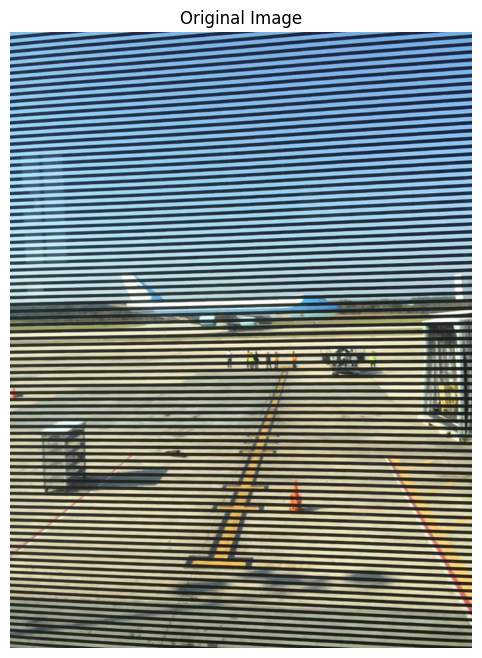

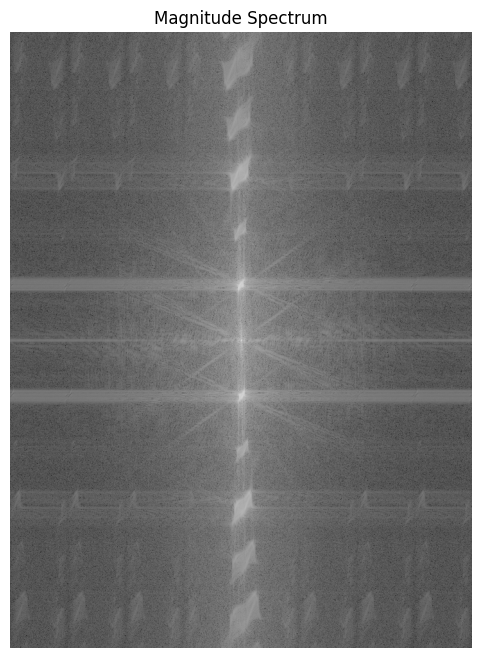

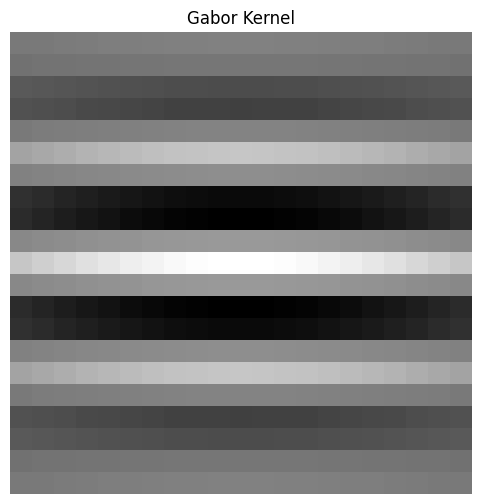

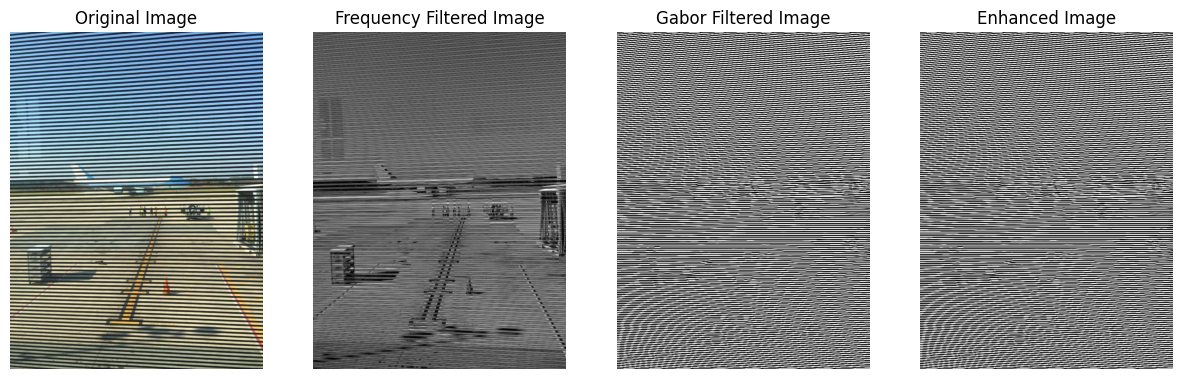

In [149]:
# Step 1: Load and display the original image
image, image_rgb = load_and_display_image(image_path)

# Step 2: Convert to grayscale for processing
image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Step 3: Apply frequency domain filtering
frequency_filtered_image = apply_frequency_filter(image_gray)

# Step 4: Apply Gabor filter
gabor_filtered_image = apply_gabor_filter(frequency_filtered_image)

# Step 5: Enhance the image
img_enhanced = enhance_image(gabor_filtered_image)

# Step 6: Display results
plt.figure(figsize=(15, 15))

plt.subplot(1, 4, 1)
plt.title("Original Image")
plt.imshow(image_rgb)
plt.axis("off")

plt.subplot(1, 4, 2)
plt.title("Frequency Filtered Image")
plt.imshow(frequency_filtered_image, cmap='gray')
plt.axis("off")

plt.subplot(1, 4, 3)
plt.title("Gabor Filtered Image")
plt.imshow(gabor_filtered_image, cmap='gray')
plt.axis("off")

plt.subplot(1, 4, 4)
plt.title("Enhanced Image")
plt.imshow(cv2.cvtColor(img_enhanced, cv2.COLOR_GRAY2RGB))
plt.axis("off")

plt.show()